# 076_refactor — the A-series models on the new data model

This notebook is a **demonstration**, not a results notebook. It runs A0/A1/A2 on top of
`phd_project/scripts/fragility_data_models.py` so the API can be judged before notebook `073`
is migrated onto it.

## The problem it solves

Notebook `073` grew a naming problem rather than a data model. Every array in it encoded **four
independent axes** into a single identifier:

| axis | how `073` spells it |
|---|---|
| arm | `mss` / `mfx` / `ifx` / `mgr` / `igr` |
| quantity (θ or β) | a `theta_`/`beta_` prefix, or the `at`/`ab` letters |
| scope (120 rows vs 51 designs) | a `_gr` suffix |
| kind (replicates vs point estimate) | an `_est` suffix, or nothing |

Four axes × five arms is about thirty module-level names before a single model is fitted, and
every new rung of the roadmap multiplies them again. Two consequences are bugs rather than
style:

1. `y0`, `v0_boot`, `lb`, `ub`, `T_sq` and friends are **silently rebound** by A1 and again by
   A2, so A0's forest plot cannot be redrawn after A1 has run.
2. `073` cannot run as committed: it hardcodes `K_SAMPLES = 10` against clouds that now hold
   5000 replicates, and passes three arguments to a two-argument function.

## The fix, in one sentence

Make the four axes **fields of two small objects** (`FragilityData`, `Contrast`), and make the
roadmap id the **key of a third** (`ModelRegistry`).

The analogy: `073` keeps its data the way someone keeps papers by writing the subject, the
year, the department and the draft number into one long filename, and then has to parse
filenames to find anything. This module puts them in labelled folders instead. Nothing about
the papers changes — but *asking a question* stops being string manipulation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import phd_project.scripts.fragility_data_models as fm
from phd_project.config import config

cfg = config.load_config()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 1.0 Load

One call replaces cells 4, 5 and 7 of `073` — five estimate frames, five replicate dicts, ten
reshapes, fourteen log transforms and a four-times-repeated `set_axis` idiom.

Two things deliberately absent from the constants below:

- **No `K_SAMPLES` literal.** The replicate count is *read from the data* and reported as
  `data.k`. Hardcoding it is what broke `073` when the bootstrap was re-run at k = 5000.
- **No storey filter.** `n_storeys=None` is the full 120-row study, which is what the project
  assumes unless told otherwise. When a filter *is* passed it is applied to the row spine and
  to nothing else, so the clouds and the estimates cannot end up at different lengths — the
  `073` failure where 60-row clouds met 120-row estimates.

In [3]:
IM_TAG = "AvgSA_03"
BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]

# Outer-bootstrap replicates used for the intervals below. 500 keeps this notebook
# responsive (REML costs ~32 ms per replicate at n = 120); use all of them,
# n_boot=theta.k, for anything reportable.
N_BOOT = 500

theta = fm.load_fragility_data(BOOTSTRAP_PTH, IM_TAG, quantity="theta")

  msa_fx   (b    ):  51 x 5000 replicates
  ida_fx   (c    ):  51 x 5000 replicates
  ida_ub   (c_ub ):  51 x 5000 replicates
  ida_avg  (c_avg):  51 x 5000 replicates
  msa_ss   (a    ): 120 x 5000 replicates
checks:
  y0 == y1 + y2[g[i]]        : ok (estimates and all replicates)
  v1 == v_a + V_bb[g,g]      : ok to MC error (implied corr mean -0.0011, max |z| 2.2 sigma)
  V_bb mean off-diag corr    : +0.4091 (min eig -5.79e-19, k/J 98.0)
  dataset var == cloud var   : ok for every loaded arm
  shape                      : n=120, J=51, sites=60, k=5000


The load prints which arms it found and the report from `check_fragility_data`. Those checks
are the ones `073` had nowhere to put; each catches a failure that is otherwise invisible or
only surfaces much later, where the cause is no longer obvious. Section 2.1 unpacks them.

Note all **five** arms load, not the three `073` uses. `ida_ub` and `ida_avg` are the upper
bound and geometric mean of the IDA collapse bracket — one analysis read three ways, not three
analyses — and they are what make section 2.4 of `073` (written up, never implemented) free.

In [4]:
print(theta.summary())

FragilityData(quantity='theta', im_tag='AvgSA_03')
  rows        : 120  (60 sites x storeys [3, 5])
  designs     : 51
  replicates  : 5000
  arms loaded : b, c, c_ub, c_avg, a


In [5]:
theta.rows.head()

structure_id               tag design_group_id  n_sites_in_group  is_representative  msa_fx_theta  msa_fx_log_theta  msa_fx_theta_bc  msa_fx_log_theta_bc  msa_fx_var_theta  \
site n_storeys                                                                                                                                                                                
0    3                     0  3s_cbf_dc2_site0     group_3s_00                 8               True      0.411665         -0.887545         0.411665            -0.887545          0.000324   
     5                    25  5s_cbf_dc2_site0     group_5s_00                21               True      0.351892         -1.044431         0.351892            -1.044431          0.000228   
1    3                     1  3s_cbf_dc2_site1     group_3s_01                 6               True      0.392731         -0.934629         0.392731            -0.934629          0.000212   
     5                    25  5s_cbf_dc2_site1     group_5s_00                21              False      0.351892         -1.044431         0.351892            -1.044431          0.000228   
2    3                     1  3s_cbf_dc2_site2     group_3s_01                 6              False      0.392731         -0.934629         0.392731            -0.934629          0.000212   

                msa_fx_var_log_theta  msa_fx_log_theta_bias  msa_fx_n_obs  ida_fx_theta  ida_fx_log_theta  ida_fx_theta_bc  ida_fx_log_theta_bc  ida_fx_var_theta  ida_fx_var_log_theta  \
site n_storeys                                                                                                                                                                            
0    3                      0.001906              -0.000105          5000      0.393142         -0.933584         0.393142            -0.933584          0.000308              0.001981   
     5                      0.001827               0.000433          5000      0.340030         -1.078723         0.340030            -1.078723          0.000176              0.001524   
1    3                      0.001356               0.000818          5000      0.382000         -0.962336         0.382000            -0.962336          0.000231              0.001573   
     5                      0.001827               0.000433          5000      0.340030         -1.078723         0.340030            -1.078723          0.000176              0.001524   
2    3                      0.001356               0.000818          5000      0.382000         -0.962336         0.382000            -0.962336          0.000231              0.001573   

                ida_fx_log_theta_bias  ...  ida_ub_var_theta  ida_ub_var_log_theta  ida_ub_log_theta_bias  ida_ub_n_obs  ida_avg_theta  ida_avg_log_theta  ida_avg_theta_bc  ida_avg_log_theta_bc  \
site n_storeys                         ...                                                                                                                                                          
0    3                      -0.000270  ...          0.000356              0.001969              -0.000214          5000       0.408397          -0.895515          0.408397             -0.895515   
     5                      -0.000450  ...          0.000188              0.001409              -0.000490          5000       0.352808          -1.041832          0.352808             -1.041832   
1    3                      -0.000215  ...          0.000246              0.001440              -0.000184          5000       0.396916          -0.924031          0.396916             -0.924031   
     5                      -0.000450  ...          0.000188              0.001409              -0.000490          5000       0.352808          -1.041832          0.352808             -1.041832   
2    3                      -0.000215  ...          0.000246              0.001440              -0.000184          5000       0.396916          -0.924031          0.396916             -0

## 2.0 What the container holds

Scope is **structural**, not a name suffix. `a` is per row (120 = 60 sites × {3s, 5s}); `b`,
`c`, `c_ub` and `c_avg` are per design group (51), because the fixed-record-set arms choose
their stripe IMLs from the fragility curve rather than from site hazard and so depend on the
design only.

That is the whole content of the `_gr` suffix in `073`: it was not a naming problem, it was a
scope with no home. There is no "`b` at site scope" — there is `Z @ b`, and `Z` lives on the
container so the expansion cannot be done two different ways in two different cells.

In [6]:
a, b, c = theta.a, theta.b, theta.c          # log medians, roadmap notation

print(f"a  (MSA-SS,  per row)    {a.shape}")
print(f"b  (MSA-FX,  per design) {b.shape}")
print(f"c  (IDA-FX,  per design) {c.shape}")
print()
print(f"n = {theta.n} rows, J = {theta.J} designs, {theta.n_sites} sites, k = {theta.k}")
print(f"Z (row -> design) {theta.Z.shape}      S (row -> site) {theta.S.shape}")
print()
# g[i] and sigma[i] in the Gelman & Hill square-bracket notation the project uses.
print("g[i]     (first 8):", theta.g[:8])
print("sigma[i] (first 8):", theta.site_codes[:8])

a  (MSA-SS,  per row)    (120, 5000)
b  (MSA-FX,  per design) (51, 5000)
c  (IDA-FX,  per design) (51, 5000)

n = 120 rows, J = 51 designs, 60 sites, k = 5000
Z (row -> design) (120, 51)      S (row -> site) (120, 60)

g[i]     (first 8): [ 0 25  1 25  1 25  2 25]
sigma[i] (first 8): [0 0 1 1 2 2 3 3]


In [7]:
dir(theta)

['J',
 'S',
 'V_aa',
 'V_bb',
 'V_bc',
 'V_cc',
 'Z',
 '__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'a',
 'a_hat',
 'available',
 'b',
 'b_hat',
 'c',
 'c_hat',
 'contrast',
 'cov',
 'estimates',
 'estimates_bc',
 'expand',
 'g',
 'groups',
 'hat',
 'im_tag',
 'k',
 'n',
 'n_sites',
 'quantity',
 'rep',
 'reps',
 'rows',
 'scope_of',
 'site_codes',
 'sites',
 'summary',
 'term',
 'to_rows']

### 2.1 The crossed structure, and why `V_known` is not diagonal

Design and site are **crossed, not nested**: a design spans several sites and a site hosts two
structures. The two facts that follow are the reason the sampling covariance has to be carried
as a matrix rather than a vector of variances:

- **`V_bb` is dense.** Every design is fitted to the *same* fixed record set with the same
  bootstrap index sets, so a replicate that happens to draw strong records pushes every `b_j`
  the same way. Independent errors average away at $1/\sqrt{n}$; this shared component does
  not average away at all.
- **`V_aa` is block-diagonal by site**, with a 2×2 block per site — the 3-storey and 5-storey
  structures at a site share records wherever they are analysed at the same stripe IML.

Below, the mean off-diagonal correlation of `V_bb` is the number that matters. If it were ≈ 0
the replicates never shared record indices and the whole argument would be vacuous.

In [8]:
n_show = 8
print("V_bb correlation matrix, first 8 designs "
      "(dense off-diagonal = the shared record set):")
V = theta.V_bb
D = np.sqrt(np.diag(V))
print(pd.DataFrame((V / np.outer(D, D))[:n_show, :n_show],
                   index=theta.groups[:n_show], columns=theta.groups[:n_show]).round(3))

offdiag = (V / np.outer(D, D))[~np.eye(theta.J, dtype=bool)]
print(f"\nmean off-diagonal correlation of V_bb : {offdiag.mean():+.4f}")
print("A diagonal V would throw exactly this away - and it is what makes the "
      "model-based SE too small (see section 4.1).")

V_bb correlation matrix, first 8 designs (dense off-diagonal = the shared record set):
design_group_id  group_3s_00  group_3s_01  group_3s_02  group_3s_03  group_3s_04  group_3s_05  group_3s_06  group_3s_07
design_group_id                                                                                                        
group_3s_00            1.000        0.691        0.931        0.746        0.662        0.640        0.658        0.648
group_3s_01            0.691        1.000        0.675        0.880        0.857        0.898        0.893        0.905
group_3s_02            0.931        0.675        1.000        0.778        0.597        0.650        0.695        0.640
group_3s_03            0.746        0.880        0.778        1.000        0.832        0.813        0.820        0.800
group_3s_04            0.662        0.857        0.597        0.832        1.000        0.875        0.855        0.878
group_3s_05            0.640        0.898        0.650        0.813      

## 3.0 Contrasts

Everything in the roadmap is a contrast of `a`, `b` and `c`:

$$y^{(0)}_i = a_i - c_{g[i]},\qquad y^{(1)}_i = a_i - b_{g[i]},\qquad y^{(2)}_j = b_j - c_j$$

A `Contrast` carries the point estimates, the replicate matrix, the **full** sampling
covariance `V`, its diagonal `v`, and the factor table for its own rows. Carrying `V` beside
`v` is the point of the object: DerSimonian–Laird can only use `v`, REML needs `V`, and the
gap between the two is itself a finding.

`y2` is built at group scope and **stays** there. Replicating it to 120 rows would invent 69
rows of information that does not exist and shrink $SE(m_2)$ by about $\sqrt{120/51}\approx1.53$
for nothing.

In [9]:
for name in ("y0", "y1", "y2"):
    print(theta.contrast(name).summary())

y0 = a - c  (MSA-SS / IDA-FX), row scope, n=120, k=5000, mean ratio 1.0415
y1 = a - b  (MSA-SS / MSA-FX), row scope, n=120, k=5000, mean ratio 0.9984
y2 = b - c  (MSA-FX / IDA-FX), group scope, n=51, k=5000, mean ratio 1.0448


In [10]:
aa = theta.contrast("y0")
aa.v

site  n_storeys
0     3            0.002978
      5            0.002650
1     3            0.002236
      5            0.002259
2     3            0.002307
                     ...   
57    5            0.002896
58    3            0.001818
      5            0.002879
59    3            0.003520
      5            0.001801
Name: v_y0, Length: 120, dtype: float64

In [11]:
dir(theta.contrast("y0"))

['V',
 '__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'diag_V',
 'forest_frame',
 'g',
 'k',
 'label',
 'labels',
 'n',
 'name',
 'quantiles',
 'quantity',
 'rows',
 'scope',
 'site_codes',
 'summary',
 'terms',
 'v',
 'y',
 'y_hat']

### 3.1 The identity that ties the roadmap together

$$y^{(0)}_i \equiv y^{(1)}_i + y^{(2)}_{g[i]}\qquad\text{for every } i$$

This holds **exactly**, not approximately, because `y2` is constant within a design group. It
is therefore a free and extremely sharp test that `Z`, the label-based expansion and the
replicate alignment are all correct *at the same time* — a positional row mapping, a dropped
level or a misaligned replicate would each break it. `check_fragility_data` runs it on the
point estimates and on all 5000 replicates at load time; here it is again, explicitly.

In [12]:
y0, y1, y2 = (theta.contrast(n) for n in ("y0", "y1", "y2"))
lhs = y0.y_hat
rhs = y1.y_hat + theta.expand(y2.y_hat)

print(f"max |y0 - (y1 + y2[g[i]])| : {np.abs(lhs - rhs).max():.3e}   (estimates)")
print(f"max |y0 - (y1 + y2[g[i]])| : "
      f"{np.abs(y0.y - (y1.y + theta.expand(y2.y))).to_numpy().max():.3e}   "
      f"(all {theta.k} replicates)")

max |y0 - (y1 + y2[g[i]])| : 0.000e+00   (estimates)
max |y0 - (y1 + y2[g[i]])| : 5.551e-17   (all 5000 replicates)


## 4.0 The models

`073` spends six cells per model — effect sizes, forest plot, heterogeneity, replicate refits,
intervals, SE comparison — and repeats them three times, with three of the six cells
byte-identical between models. Here a rung is a `ModelSpec` entry and a fit is one call.

The registry **refuses to overwrite** a fit unless told to. That is the direct fix for the
silent rebinding: in `073`, re-running the A1 block after A2 leaves A2's numbers in variables
named as though they were A1's, and nothing complains.

In [13]:
fits = fm.ModelRegistry(theta)

for model_id in ("A0a", "A1a", "A2"):
    fits.fit(model_id, n_boot=N_BOOT, verbose=True)

print("\nfitted:", fits.fitted)

  A0a [DL]: outer bootstrap over 500 replicates...
  A0a [REML]: outer bootstrap over 500 replicates...
  A1a [DL]: outer bootstrap over 500 replicates...
  A1a [REML]: outer bootstrap over 500 replicates...
  A2 [DL]: outer bootstrap over 500 replicates...
  A2 [REML]: outer bootstrap over 500 replicates...

fitted: [('A0a', 'DL'), ('A0a', 'REML'), ('A1a', 'DL'), ('A1a', 'REML'), ('A2', 'DL'), ('A2', 'REML')]


In [14]:
print(fits["A0a"].summary())

A0a [REML]  MSA-SS / IDA-FX  (y0 = a - c, theta, n=120)
  summary effect   : 1.0719   (log +0.0695)
  95% CI           : 1.0203 - 1.1102     <- where the MEAN effect lies
  95% PI           : 0.8997 - 1.2772     <- where the NEXT case lands
  SE (superpop.)   : 0.02346   <- includes tau: a NEW structure
  SE (sampling)    : 0.02049   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02043   <- 500 refits
  tau_u            : 0.0861   (a factor of 1.090)
  The headline: site-specific MSA against fixed-set IDA, intercept only. exp(m0) is the correction factor an engineer would apply to a FEMA-P695-style IDA fragility to get the site-specific answer. Fitted with the FULL V. Every row in a design group subtracts the SAME c_j, so the sampling errors are correlated across rows and a diagonal V would understate SE(m0). Report the prediction interval alongside the confidence interval (Borenstein Ch. 17, not Ch. 14): the CI says where the MEAN correction lies, the PI says where the NEXT 

### 4.1 Three standard errors, and why they differ

The summary above prints three. They are not competing estimates of one quantity — they answer
three different questions, and the fit is only interpretable once you know which one you want.

Write the estimator as a weighted mean, $\hat m = w'y$. For REML those weights are the GLS row
$w = (X'\Sigma^{-1}X)^{-1}X'\Sigma^{-1}$ with $\Sigma = V + \hat\tau_u^2 I$.

| line | formula | question it answers |
|---|---|---|
| `SE (superpop.)` | $\sqrt{(X'\Sigma^{-1}X)^{-1}}$ | how well is the mean correction known for a **new** structure drawn from the same population? |
| `SE (sampling)` | $\sqrt{w'Vw}$ | how well is it known **for these 120 structures**? |
| `SE (bootstrap)` | $\operatorname{sd}_r(M^*)$ over the refits | the same question, measured rather than derived |

**Why the bootstrap matches `SE (sampling)` and not `SE (superpop.)`.** The replicates resample
*records only*. The same 60 sites and 51 designs appear in every replicate, so the true effects
$\alpha_i-\gamma_{g[i]}$ are held fixed and only the record-sampling error is perturbed. The
bootstrap therefore measures how that error propagates through the weights — which is exactly
$w'Vw$. It has no way to see $\tau_u$, because nothing in the resampling generates a *new*
building.

`SE (superpop.)` is larger precisely because it adds that: $\Sigma$ carries $\hat\tau_u^2$, so it
treats the 120 rows as a sample from a population of buildings and charges for the fact that the
next one will be different. This is the finite-population vs superpopulation distinction of
Gelman & Hill Ch. 21.2 (~pp. 458–460), which the roadmap already cites.

So the two agreeing to Monte-Carlo error is a **check**, not a coincidence — if they disagreed,
the bootstrap would not be carrying the covariance the fit was handed. That is what the
diagnostic line in the summary now tests. (`SE (sampling)` and `SE (bootstrap)` are computed from
different numbers of replicates — $V$ from all 5000, the refits from `N_BOOT` — so expect
agreement to about $1/\sqrt{2\,N_{\text{boot}}}$, roughly 3% at 500.)

**Which to report.** For the headline correction factor, the superpopulation SE, since the point
of the exercise is a factor to apply to a building not in this study. The prediction interval
already does this properly, and is the number an engineer should actually read. Use the
bootstrap SE when the claim is about *this* dataset — for example when comparing two estimators
on it, as in the next cell.

### 4.2 The same three numbers for DerSimonian–Laird

DL assumes a **diagonal** sampling covariance — `mra.compute_re_summary_effect` takes a variance
*vector*, so there is nowhere for the off-diagonal to go. That costs it twice, and the two costs
are worth separating because only one of them is a reporting error.

In [15]:
print(fits["A0a", "DL"].summary())

A0a [DL]  MSA-SS / IDA-FX  (y0 = a - c, theta, n=120)
  summary effect   : 1.0398   (log +0.0390)
  95% CI           : 0.9846 - 1.0932     <- where the MEAN effect lies
  95% PI           : 0.8726 - 1.2390     <- where the NEXT case lands
  SE (superpop.)   : 0.00906   <- includes tau: a NEW structure
  SE (sampling)    : 0.02577   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02514   <- 500 refits
    -> fitted with a DIAGONAL sampling covariance: the model-based SE omits the off-diagonal entirely, and the weights ignore that rows in a design share an arm.
  tau_u            : 0.0849   (a factor of 1.089)
  Q                : 456.52 on 119 df   (excess over null +337.52)
  I_sq             : 73.9%   (secondary - see Borenstein Ch. 16: I_sq is a PROPORTION of variance that is real, and with small sampling variances it tends to 1 almost regardless)
  The headline: site-specific MSA against fixed-set IDA, intercept only. exp(m0) is the correction factor an engineer would apply

**1. Its model-based SE is simply wrong.** It comes out around 0.009 against a sampling SE of
about 0.026 — nearly three times too small. DL has no way to know that every row in a design
group subtracts the *same* $c_j$, so it counts correlated rows as independent evidence and the
effective sample size is far below 120. Note this is *not* the superpopulation-vs-finite-population
distinction of §4.1: DL's formula does include $\hat\tau^2$ in its weights, so it is a
superpopulation SE in kind — it is just computed with the off-diagonal deleted.

**2. Its point estimator is less efficient.** Compare the *sampling* SEs, which is the
like-for-like comparison: DL ≈ 0.026 against REML's ≈ 0.020 on identical replicates. Both are
weighted means $\hat m = w'y$ differencing the same data; only $w$ differs. DL's weights are all
positive and nearly equal (they span about 0.0058–0.0093), while REML's GLS weights range from
about −0.010 to +0.034. The negative weights are not a defect — they are GLS recognising that a
row sharing a $c_j$ with several others carries duplicated information, and subtracting it to
cancel the common error. Ignoring the correlation does not just misreport the precision; it
throws precision away.

In [16]:
print(fits["A1a"].summary())

A1a [REML]  MSA-SS / MSA-FX  (y1 = a - b, theta, n=120)
  summary effect   : 0.9976   (log -0.0024)
  95% CI           : 0.9409 - 1.0533     <- where the MEAN effect lies
  95% PI           : 0.8359 - 1.1905     <- where the NEXT case lands
  SE (superpop.)   : 0.00916   <- includes tau: a NEW structure
  SE (sampling)    : 0.02766   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.02728   <- 500 refits
    -> fitted with a DIAGONAL sampling covariance: the model-based SE omits the off-diagonal entirely, and the weights ignore that rows in a design share an arm.
  tau_u            : 0.0850   (a factor of 1.089)
  Site-specific MSA against fixed-set MSA: the pure record-set effect, with the analysis procedure held constant. This is the one rung where a DIAGONAL V_known is exactly correct, and it is worth being clear why. v1[i] = v_a[i] + V_bb[g[i], g[i]] holds exactly because the SS and FX arms use disjoint record sets, so their cross term is zero. That makes A1a the regression 

In [17]:
print(fits["A2"].summary())

A2 [REML]  MSA-FX / IDA-FX  (y2 = b - c, theta, n=51)
  summary effect   : 1.0450   (log +0.0441)
  95% CI           : 1.0421 - 1.0498     <- where the MEAN effect lies
  95% PI           : 1.0244 - 1.0660     <- where the NEXT case lands
  SE (superpop.)   : 0.00245   <- includes tau: a NEW structure
  SE (sampling)    : 0.00156   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.00178   <- 500 refits
  tau_u            : 0.0097   (a factor of 1.010)
  Fixed-set MSA against fixed-set IDA, at 51 rows because one row IS one design -- the fixed-set stripe IMLs come from the fragility curve, not from site hazard, so these arms depend on the design only. Replicating to 120 rows would invent information and shrink SE(m2) by about 1.53 for nothing. Both arms share one record set, so the record effect cancels and what is left is the PROCEDURE effect: stripe-count binomial MLE against lognormal-of-capacities. Expect a small non-zero m2 for that reason and say so up front, so that a non-

### 4.3 One forest plot helper, not three copies

Plotted on the ratio scale with a reference line at 1.0, because a log-ratio of 0 is harder to
read than a ratio of 1 and the ratio is the reportable form.

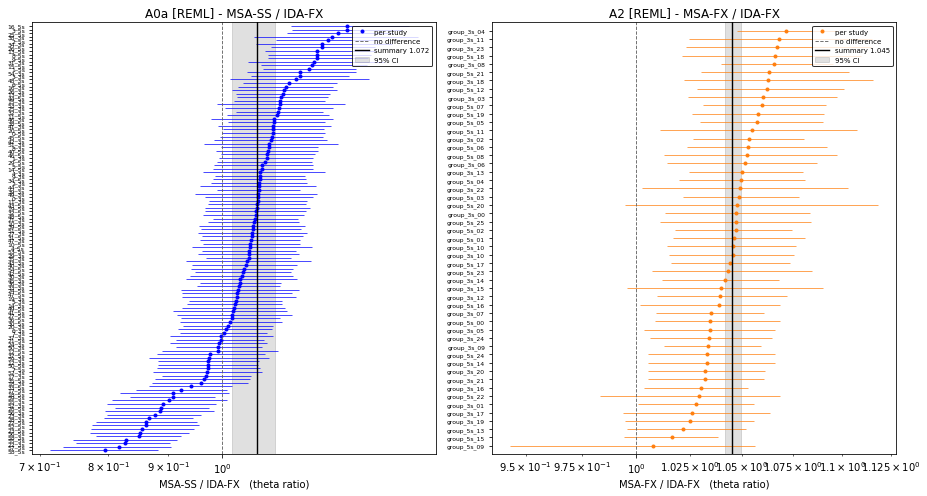

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fits.forest("A0a", ax=axes[0])#, max_rows=40)
fits.forest("A2", ax=axes[1])
fig.tight_layout()
plt.show()

## 5.0 The comparison table

One call across every fit — something `073` has no equivalent of, because its results live in
suffixed variables that have to be collected by hand.

Everything is in **ratio units**: `ratio` is the summary effect as a factor, `tau_u` the
case-to-case SD on the log scale, and `ci_*`/`pi_*` the confidence and prediction intervals.

In [19]:
cols = ["contrast", "n", "ratio", "se_model", "se_sampling", "se_boot",
        "tau_u", "ci_lo", "ci_hi", "pi_lo", "pi_hi"]
fits.table()[cols].round(4)


contrast    n   ratio  se_model  se_sampling  se_boot   tau_u   ci_lo   ci_hi   pi_lo   pi_hi
model estimator                                                                                              
A0a   DL              y0  120  1.0398    0.0091       0.0258   0.0251  0.0849  0.9846  1.0932  0.8726  1.2390
      REML            y0  120  1.0719    0.0235       0.0205   0.0204  0.0861  1.0203  1.1102  0.8997  1.2772
A1a   DL              y1  120  0.9975    0.0091       0.0277   0.0273  0.0837  0.9409  1.0533  0.8380  1.1875
      REML            y1  120  0.9976    0.0092       0.0277   0.0273  0.0850  0.9409  1.0533  0.8359  1.1905
A2    DL              y2   51  1.0436    0.0022       0.0034   0.0034  0.0000  1.0384  1.0521  1.0364  1.0508
      REML            y2   51  1.0450    0.0024       0.0016   0.0018  0.0097  1.0421  1.0498  1.0244  1.0660

Read across the three SE columns with §4.1 in mind. `se_model` is the superpopulation SE (it
carries $\tau$), `se_sampling` is $\sqrt{w'Vw}$ and `se_boot` is its measured counterpart; the
last two should agree to Monte-Carlo error for every row. Where `se_sampling` is much *larger*
than a sibling fit's, that estimator is throwing precision away — compare the DL and REML rows
of `A0a`.

### Does the decomposition add up?

`y1` is the pure **record-set** effect (procedure held constant) and `y2` the pure **procedure**
effect (records held constant), so it is tempting to read `ratio` down the table and expect
$m_0 = m_1 + m_2$. Be careful: **that holds at row level, but not for these fitted summaries.**

The row-level identity is exact, and §3.1 checked it to $10^{-17}$:

$$y^{(0)}_i \equiv y^{(1)}_i + y^{(2)}_{g[i]}$$

But each $\hat m$ is a *weighted* mean $\hat m = w'y$, and weighted means only add when the
weights match — you need $w_0 = w_1$ and $w_0'Z = w_2'$. Nothing makes that true, because each
fit chooses weights from its own sampling covariance, and those covariances genuinely differ:
`y0` carries $V_{aa} + ZV_{cc}Z'$ while `y1` carries $V_{aa} + ZV_{bb}Z'$.

What actually happens on this data:

| | $m_0$ | $m_1 + m_2$ | gap | $\mathrm{corr}(w_0, w_1)$ |
|---|---|---|---|---|
| DL | +0.0390 | +0.0402 | −0.0012 | 0.78 |
| REML | +0.0695 | +0.0416 | **+0.0279** | 0.16 |

**DL nearly adds up** because its weights are all positive and span a narrow range, so all three
fits are close to *unweighted* means — and unweighted means add exactly, straight from the
row-level identity. Its residual 0.0012 is just how far its weights depart from uniform.

**REML does not**, and this is not a defect. Its GLS weight vectors for `y0` and `y1` are nearly
uncorrelated (0.16) and contain negative entries, so applying $w_0$ to `y1` gives $+0.0279$ where
$\hat m_1 = -0.0024$. That single term is essentially the whole gap; the `y2` term contributes
little. Adding two separately-fitted GLS means is simply not a meaningful operation.

This is the "different form" problem of `analysis_models.md` §3. The fix there is not to patch
the arithmetic but to fit a **joint** model on the contrasts (A11), in which $m_1 + m_2$ *is*
$m_0$ by construction. A9 gives the cheap frequentist version: inside each bootstrap replicate
fit A1 and A2, store $\hat m_1^{(r)}$ and $\hat m_2^{(r)}$, and take their covariance — which
also yields the (negative, since `b` enters with opposite signs) correlation needed for
$\mathrm{SE}(\hat m_1 + \hat m_2)$. Neither is implemented here.

Until then, read `y1` and `y2` as answering *what kind* of effect each is, not as addends.

## 6.0 The collapse-bracket arms — section 2.4 of `073`

Notebook `073` describes an analysis against the geometric-average IDA arm and never
implements it. Here it is already in the registry: the three IDA arms are one analysis read
three ways off the collapse bracket, so they are three alternative `c` terms.

Read the spread across them as a **sensitivity band** on A0/A2 — the cost of where inside the
bracket each record's capacity is placed — not as three independent findings.

In [20]:
for model_id in ("A0a_avg", "A0a_ub", "A2_avg", "A2_ub"):
    fits.fit(model_id, n_boot=N_BOOT)

band = fits.table(["A0a", "A0a_avg", "A0a_ub", "A2", "A2_avg", "A2_ub"])
band.loc[(slice(None), "REML"), ["contrast", "n", "ratio", "ci_lo", "ci_hi"]].round(4)

,,contrast,n,ratio,ci_lo,ci_hi
model,estimator,,,,,
A0a,REML,y0,120,1.0719,1.0203,1.1102
A2,REML,y2,51,1.0450,1.0421,1.0498
A0a_avg,REML,y0_avg,120,1.0332,0.9834,1.0697
A0a_ub,REML,y0_ub,120,0.9958,0.9478,1.0304
A2_avg,REML,y2_avg,51,1.0057,1.0027,1.0109
A2_ub,REML,y2_ub,51,0.9680,0.9649,0.9739


## 7.0 The β scale — roadmap A12–A16, for one argument

The roadmap repeats the whole ladder on the dispersion. On the new data model that is
`quantity="beta"` and **nothing else**: no new model code, no parallel set of `beta_`-prefixed
variable names.

This section is both the demonstration and the test of whether the design worked. If it had
needed a single change to the model layer, it would have failed.

One caveat worth carrying into the write-up: $\hat\beta$ is noisier than $\hat\theta$ at the
same record count and its sampling distribution is more skewed, so the normal-on-the-log-scale
approximation is weaker here. Check the skew of the bootstrap distribution before leaning on
it.

In [21]:
beta = fm.load_fragility_data(BOOTSTRAP_PTH, IM_TAG, quantity="beta")

beta_fits = fm.ModelRegistry(beta)
for model_id in ("A0a", "A1a", "A2"):
    beta_fits.fit(model_id, n_boot=N_BOOT)

beta_fits.table()[cols].round(4)

[autoreload of phd_project.scripts.fragility_data_models failed: Traceback (most recent call last):
  File "c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 524, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "C:\Users\clemettn\Documents\pyversions\py3_12_10\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 73597: character maps to <undefined>
]


  msa_fx   (b    ):  51 x 5000 replicates
  ida_fx   (c    ):  51 x 5000 replicates
  ida_ub   (c_ub ):  51 x 5000 replicates
  ida_avg  (c_avg):  51 x 5000 replicates
  msa_ss   (a    ): 120 x 5000 replicates
checks:
  y0 == y1 + y2[g[i]]        : ok (estimates and all replicates)
  v1 == v_a + V_bb[g,g]      : ok to MC error (implied corr mean -0.0003, max |z| 3.4 sigma)
  V_bb mean off-diag corr    : +0.1395 (min eig -2.26e-18, k/J 98.0)
  dataset var == cloud var   : ok for every loaded arm
  shape                      : n=120, J=51, sites=60, k=5000


contrast    n   ratio  se_model  se_sampling  se_boot   tau_u   ci_lo   ci_hi   pi_lo   pi_hi
model estimator                                                                                              
A0a   DL              y0  120  1.1271    0.0236       0.0573   0.0606  0.1581  1.0420  1.3204  0.8060  1.5762
      REML            y0  120  1.0909    0.0477       0.0458   0.0483  0.0910  1.0286  1.2398  0.8896  1.3379
A1a   DL              y1  120  1.1508    0.0264       0.0834   0.0880  0.1558  0.9823  1.3848  0.8075  1.6402
      REML            y1  120  1.1509    0.0264       0.0834   0.0880  0.1567  0.9823  1.3848  0.8063  1.6427
A2    DL              y2   51  1.0061    0.0156       0.0313   0.0305  0.0000  0.9559  1.0722  0.9464  1.0696
      REML            y2   51  0.9841    0.0231       0.0152   0.0169  0.0871  0.9677  1.0378  0.8234  1.1762

In [22]:
print(beta_fits["A0a"].summary())

A0a [REML]  MSA-SS / IDA-FX  (y0 = a - c, beta, n=120)
  summary effect   : 1.0909   (log +0.0870)
  95% CI           : 1.0286 - 1.2398     <- where the MEAN effect lies
  95% PI           : 0.8896 - 1.3379     <- where the NEXT case lands
  SE (superpop.)   : 0.04774   <- includes tau: a NEW structure
  SE (sampling)    : 0.04579   <- sqrt(w' V w), these structures
  SE (bootstrap)   : 0.04830   <- 500 refits
  tau_u            : 0.0910   (a factor of 1.095)
  The headline: site-specific MSA against fixed-set IDA, intercept only. exp(m0) is the correction factor an engineer would apply to a FEMA-P695-style IDA fragility to get the site-specific answer. Fitted with the FULL V. Every row in a design group subtracts the SAME c_j, so the sampling errors are correlated across rows and a diagonal V would understate SE(m0). Report the prediction interval alongside the confidence interval (Borenstein Ch. 17, not Ch. 14): the CI says where the MEAN correction lies, the PI says where the NEXT b

## 8.0 What stage 2 would change

Nothing above touches notebooks `072` or `073`. If this API is right, stage 2 is:

**`072`** stops owning names and paths that two notebooks need — the inline `ARMS` dict, the
dataset filename, the design-group label convention and the mechanical half of `arm_columns`
move into `fragility_data_models.py`. Every cross-file assertion **stays** in `072`: they tie
together files written by different cells of `070` and are the actual purpose of that
notebook. Acceptance is a byte-identical CSV.

**`073`** loses roughly 50 lines of setup and 18 cells of copy-pasted model blocks, and gains
the comparison table, the collapse-bracket section it never implemented, and the ability to
re-run a model without corrupting an earlier one. Its stale `K_SAMPLES = 10`, its unused
`N_STOREYS`, its three-argument call to a two-argument function and its dead commented
constants all go.

Two things worth deciding before then:

- **A1b and A1c are deliberately absent.** The crossed design × site fit is the reportable A1
  rung, and all the machinery for it is already here (`theta.Z`, `theta.S`, `ModelSpec.components`).
  Adding them is two table entries — but they were out of scope for this pass, so they have
  not been fitted or checked.
- **`mra.compute_heterogeneity_stats` returns `Q_df = Q - (n-1)`**, which is the *excess* of Q
  over its null expectation, not the degrees of freedom. `ModelFit` reports both under their
  own names rather than propagating the mislabel, but `mra` itself is untouched.